# Figure-Ready Data Assembly: JRN Paper Visualization Specifications

This notebook demonstrates the evaluation pipeline that assembles figure-ready data from 5 JRN (Join Reproduction Number) experiments into 6 paper figures:

1. **JRN Heatmaps** — Join × Task matrices with hierarchical clustering
2. **Cross-Task Transfer** — Pairwise Spearman correlation matrices (Kendall's W 0.21–0.52)
3. **Cost-Efficiency Curves** — Convergence configs and method comparisons
4. **Compounding Models** — Log-linear vs multiplicative model fits (best R²=0.83)
5. **FK-Shuffling Decomposition** — Structural vs feature signal (Cohen's d 0.63–0.69)
6. **Probe Validity** — Forest plots and cheapest probe correlation (ρ=0.954)

The demo loads pre-computed figure-ready data and recomputes aggregate metrics and visualizations.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    # Colab has scipy==1.16.3 (Python >=3.11); use 1.15.3 for Python 3.10
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os
import sys

import numpy as np
from scipy import stats
from scipy.cluster.hierarchy import linkage, leaves_list
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/evaluation_iter7_figure_ready_da/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded: {data['metadata']['evaluation_name']}")
print(f"Figures: {data['metadata']['n_figures']}")
print(f"Datasets: {[ds['dataset'] for ds in data['datasets']]}")
print(f"Total examples: {sum(len(ds['examples']) for ds in data['datasets'])}")
print(f"\nAggregate metrics:")
for k, v in data['metrics_agg'].items():
    print(f"  {k}: {v}")

Loaded: Figure-Ready Data Assembly
Figures: 6
Datasets: ['jrn_heatmap', 'cross_task_transfer', 'cost_efficiency', 'compounding_models', 'fk_shuffling', 'probe_validity']
Total examples: 13

Aggregate metrics:
  n_figures: 6.0
  n_total_data_points: 106.0
  n_datasets_covered: 2.0
  n_experiments_synthesized: 5.0
  n_joins_total: 24.0
  n_tasks_total: 8.0
  jrn_range_min: 0.6496674420522361
  jrn_range_max: 1.2675927076126612
  kendalls_W_min: 0.20606060606060606
  kendalls_W_max: 0.5243956043956044
  best_compounding_R2: 0.8261755413022861
  structural_cohens_d_min: 0.6299145577519254
  structural_cohens_d_max: 0.6915
  n_heatmap_examples: 26.0
  n_transfer_examples: 2.0
  n_cost_examples: 5.0
  n_compounding_examples: 54.0
  n_shuffling_examples: 16.0
  n_validity_examples: 3.0
  cheapest_probe_rho: 0.954


## Configuration

Tunable parameters for the figure-ready data analysis.

In [5]:
# ── Config ──
N_SEEDS = 3              # Number of seeds for CI computation
CI_Z = 1.96              # Z-score for 95% confidence interval
JRN_GREEN_THRESH = 1.15  # JRN threshold for 'green' category
JRN_RED_THRESH = 0.85    # JRN threshold for 'red' category
MAX_EXAMPLES_PER_FIGURE = 100  # Max examples to process per figure type

## Processing: Parse Figure Datasets

Organize the loaded data by figure type and extract key metrics from each example.

In [6]:
# Organize examples by figure type
examples_by_figure = {}
for ds in data['datasets']:
    ds_name = ds['dataset']
    examples_by_figure[ds_name] = ds['examples'][:MAX_EXAMPLES_PER_FIGURE]
    print(f"{ds_name}: {len(examples_by_figure[ds_name])} examples")

print(f"\nTotal figure types: {len(examples_by_figure)}")

jrn_heatmap: 3 examples
cross_task_transfer: 2 examples
cost_efficiency: 2 examples
compounding_models: 2 examples
fk_shuffling: 2 examples
probe_validity: 2 examples

Total figure types: 6


## Metric 1: JRN Heatmap Analysis

Parse JRN heatmap data — matrix values, color categories, and hierarchical clustering orders.

In [7]:
# Parse JRN heatmap examples
heatmap_examples = examples_by_figure.get('jrn_heatmap', [])
heatmap_summaries = []
heatmap_details = []

for ex in heatmap_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    fig_type = inp.get('figure', '')
    
    if fig_type == 'jrn_heatmap':
        heatmap_summaries.append({
            'dataset': inp['dataset'],
            'n_joins': inp['n_joins'],
            'n_tasks': inp['n_tasks'],
            'matrix': np.array(out['matrix_values']),
            'row_labels': out['row_labels'],
            'col_labels': out['col_labels'],
            'color_categories': out['color_categories'],
            'row_means': out['row_means'],
            'col_means': out['col_means'],
            'jrn_range': out['jrn_range'],
        })
        print(f"Heatmap summary: {inp['dataset']} ({inp['n_joins']} joins × {inp['n_tasks']} tasks)")
        print(f"  JRN range: [{out['jrn_range'][0]:.3f}, {out['jrn_range'][1]:.3f}]")
        print(f"  Green/Yellow/Red: {out['n_green']}/{out['n_yellow']}/{out['n_red']}")
    elif fig_type == 'jrn_heatmap_detail':
        heatmap_details.append({
            'dataset': inp['dataset'],
            'join': inp['join'],
            'row_mean': ex.get('eval_row_mean_jrn', 0),
        })

print(f"\nParsed {len(heatmap_summaries)} heatmap summaries, {len(heatmap_details)} detail rows")

Heatmap summary: rel-f1 (13 joins × 5 tasks)
  JRN range: [0.292, 1.626]
  Green/Yellow/Red: 13/25/12

Parsed 1 heatmap summaries, 2 detail rows


## Metric 2: Cross-Task Transfer Analysis

Parse pairwise Spearman correlation matrices and Kendall's W concordance.

In [8]:
# Parse cross-task transfer examples
transfer_examples = examples_by_figure.get('cross_task_transfer', [])
transfer_data = []

for ex in transfer_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    
    rho_matrix = np.array(out['pairwise_rho_matrix'])
    transfer_data.append({
        'dataset': inp['dataset'],
        'n_tasks': inp['n_tasks'],
        'rho_matrix': rho_matrix,
        'task_labels': out['task_labels'],
        'kendalls_W': out['kendalls_W'],
        'same_entity_mean_rho': out.get('same_entity_mean_rho', 0),
        'cross_entity_mean_rho': out.get('cross_entity_mean_rho', 0),
    })
    print(f"Transfer: {inp['dataset']} — {inp['n_tasks']} tasks, Kendall's W = {out['kendalls_W']:.3f}")
    print(f"  Same-entity mean ρ = {out.get('same_entity_mean_rho', 0):.3f}")
    print(f"  Cross-entity mean ρ = {out.get('cross_entity_mean_rho', 0):.3f}")

print(f"\nParsed {len(transfer_data)} transfer datasets")

Transfer: rel-f1 — 5 tasks, Kendall's W = 0.524
  Same-entity mean ρ = 0.872
  Cross-entity mean ρ = 0.244
Transfer: rel-stack — 3 tasks, Kendall's W = 0.206
  Same-entity mean ρ = 0.818
  Cross-entity mean ρ = -0.695

Parsed 2 transfer datasets


## Metric 3: Cost-Efficiency Analysis

Parse convergence curves and method comparison bar data.

In [9]:
# Parse cost-efficiency examples
cost_examples = examples_by_figure.get('cost_efficiency', [])
convergence_data = []
cost_bar_data = []
breakeven_data = []

for ex in cost_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    fig_type = inp.get('figure', '')
    
    if fig_type == 'cost_efficiency_convergence':
        convergence_data.append({
            'x': out['convergence_x'],
            'y_mean': out['convergence_y_mean'],
            'threshold': out['threshold_line_y'],
            'n_configs': out['n_configs_total'],
        })
        print(f"Convergence: {out['n_configs_total']} configs")
        print(f"  Best ρ = {max(out['convergence_y_mean']):.4f}")
        print(f"  Threshold = {out['threshold_line_y']}")
    elif fig_type == 'cost_efficiency_bars':
        cost_bar_data.append({
            'task': out['task'],
            'methods': out['bar_chart_methods'],
            'n_models': out['bar_chart_n_models'],
            'times': out['bar_chart_times'],
            'perfs': out['bar_chart_perfs'],
        })
        print(f"Cost bars: {out['task']} — JRN uses {out['bar_chart_n_models'][0]} models vs greedy {out['bar_chart_n_models'][1]}")
    elif fig_type == 'cost_efficiency_breakeven':
        breakeven_data.append(out)
        print(f"Breakeven: {len(out.get('scaling_table', []))} scaling points")

print(f"\nParsed {len(convergence_data)} convergence, {len(cost_bar_data)} bar, {len(breakeven_data)} breakeven")

Convergence: 64 configs
  Best ρ = 0.9963
  Threshold = 0.9
Cost bars: driver-dnf — JRN uses 14 models vs greedy 91

Parsed 1 convergence, 1 bar, 0 breakeven


## Metric 4: Compounding Models Analysis

Parse model comparison data (R², Spearman r, RMSE) across multiplicative, additive, bottleneck, and log-linear models.

In [10]:
# Parse compounding model examples
compounding_examples = examples_by_figure.get('compounding_models', [])
model_results = []
model_summary = None

for ex in compounding_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    fig_type = inp.get('figure', '')
    
    if fig_type == 'compounding_model':
        model_results.append({
            'model': out.get('model', inp.get('model', '')),
            'probe': out.get('probe', inp.get('probe', '')),
            'dataset': out.get('dataset', ''),
            'R2': out.get('R2', 0),
            'spearman_r': out.get('spearman_r', 0),
            'RMSE': out.get('RMSE', 0),
            'n_points': out.get('n_points', out.get('n_chains', 0)),
        })
        print(f"Model: {out.get('model', '')} ({out.get('probe', '')}) — R²={out.get('R2', 0):.4f}, ρ={out.get('spearman_r', 0):.4f}")
    elif fig_type == 'compounding_model_summary':
        model_summary = out
        print(f"Best model: {out['best_model']}")

print(f"\nParsed {len(model_results)} model results")

Model: multiplicative (MLP) — R²=-4.1963, ρ=0.5560
Model: multiplicative (GBM) — R²=-6.9608, ρ=0.9078

Parsed 2 model results


## Metric 5: FK-Shuffling Decomposition

Parse structural vs feature JRN signal decomposition (Cohen's d effect sizes).

In [11]:
# Parse FK-shuffling examples
shuffling_examples = examples_by_figure.get('fk_shuffling', [])
shuffling_data = []
shuffling_cross = None

for ex in shuffling_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    fig_type = inp.get('figure', '')
    
    if fig_type == 'fk_shuffling':
        shuffling_data.append({
            'dataset': out['dataset'],
            'join_labels': out['join_labels_sorted'],
            'structural': out['structural_jrn_bars'],
            'feature': out['feature_jrn_bars'],
            'total': out['total_jrn_values'],
            'cohens_d': out['cohens_d'],
        })
        print(f"FK-shuffling: {out['dataset']} — {len(out['join_labels_sorted'])} joins, Cohen's d = {out['cohens_d']:.3f}")
    elif fig_type == 'fk_shuffling_cross_dataset':
        shuffling_cross = out
        print(f"Cross-dataset: consistent={out.get('consistent_across_datasets', False)}, both_sig={out.get('both_significant', False)}")

print(f"\nParsed {len(shuffling_data)} shuffling datasets")

FK-shuffling: rel-f1 — 13 joins, Cohen's d = 0.692

Parsed 1 shuffling datasets


## Metric 6: Probe Validity Analysis

Parse forest plot and probe validity scatter data.

In [12]:
# Parse probe validity examples
validity_examples = examples_by_figure.get('probe_validity', [])
forest_data = []
scatter_data = []

for ex in validity_examples:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    fig_type = inp.get('figure', '')
    
    if fig_type == 'probe_validity_forest':
        forest_data.append({
            'dataset': out['dataset'],
            'rows': out['forest_plot_rows'],
            'pooled_mean': out['pooled_mean'],
            'pooled_ci': out['pooled_ci'],
            'n_measurements': out['n_measurements'],
        })
        print(f"Forest: {out['dataset']} — {out['n_measurements']} measurements, pooled mean = {out['pooled_mean']:.4f}")
    elif fig_type == 'probe_validity_scatter':
        scatter_data.append({
            'x': out['scatter_x_rho'],
            'y': out['scatter_y_time'],
            'R2': out['R2'],
            'cheapest_rho': out['cheapest_rho'],
        })
        print(f"Scatter: R² = {out['R2']:.4f}, cheapest ρ = {out['cheapest_rho']:.4f}")

print(f"\nParsed {len(forest_data)} forest plots, {len(scatter_data)} scatter plots")

Forest: rel-f1 — 50 measurements, pooled mean = 1.1128
Forest: rel-stack — 33 measurements, pooled mean = 1.0764

Parsed 2 forest plots, 0 scatter plots


## Recompute Aggregate Metrics

Recompute summary statistics across all parsed figures to validate the loaded data.

In [13]:
# Recompute aggregate metrics
print("=" * 60)
print("AGGREGATE METRICS (recomputed from loaded data)")
print("=" * 60)

# JRN range from heatmaps
all_jrn_vals = []
for hs in heatmap_summaries:
    all_jrn_vals.extend(hs['row_means'])
if all_jrn_vals:
    print(f"\nJRN heatmap row means range: [{min(all_jrn_vals):.4f}, {max(all_jrn_vals):.4f}]")

# Kendall's W range
if transfer_data:
    w_vals = [td['kendalls_W'] for td in transfer_data]
    print(f"Kendall's W range: [{min(w_vals):.4f}, {max(w_vals):.4f}]")

# Best compounding model
if model_results:
    best = max(model_results, key=lambda x: x['R2'])
    probe_str = best['probe']
    print(f"Best compounding model: {best['model']} (probe={probe_str}) R²={best['R2']:.4f}")

# Cohen's d range
if shuffling_data:
    d_vals = [sd['cohens_d'] for sd in shuffling_data]
    print(f"FK-shuffling Cohen's d range: [{min(d_vals):.4f}, {max(d_vals):.4f}]")

# Probe validity
if forest_data:
    pooled_strs = [f"{fd['pooled_mean']:.4f}" for fd in forest_data]
    print(f"Probe validity pooled means: {pooled_strs}")
if scatter_data:
    print(f"Cheapest probe rho: {scatter_data[0]['cheapest_rho']:.4f}")

# Compare with stored metrics
print(f"\nStored metrics_agg (from original evaluation):")
print(f"  n_figures: {data['metrics_agg']['n_figures']:.0f}")
print(f"  n_total_data_points: {data['metrics_agg']['n_total_data_points']:.0f}")
print(f"  best_compounding_R2: {data['metrics_agg']['best_compounding_R2']:.4f}")
cheapest = data['metrics_agg'].get('cheapest_probe_rho', 'N/A')
print(f"  cheapest_probe_rho: {cheapest}")

AGGREGATE METRICS (recomputed from loaded data)

JRN heatmap row means range: [0.6497, 1.1456]
Kendall's W range: [0.2061, 0.5244]
Best compounding model: multiplicative (probe=MLP) R²=-4.1963
FK-shuffling Cohen's d range: [0.6915, 0.6915]
Probe validity pooled means: ['1.1128', '1.0764']

Stored metrics_agg (from original evaluation):
  n_figures: 6
  n_total_data_points: 106
  best_compounding_R2: 0.8262
  cheapest_probe_rho: 0.954


## Visualization

Multi-panel figure showing key results from each of the 6 figure types.

/tmp/ipykernel_1010/1877213093.py:137: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


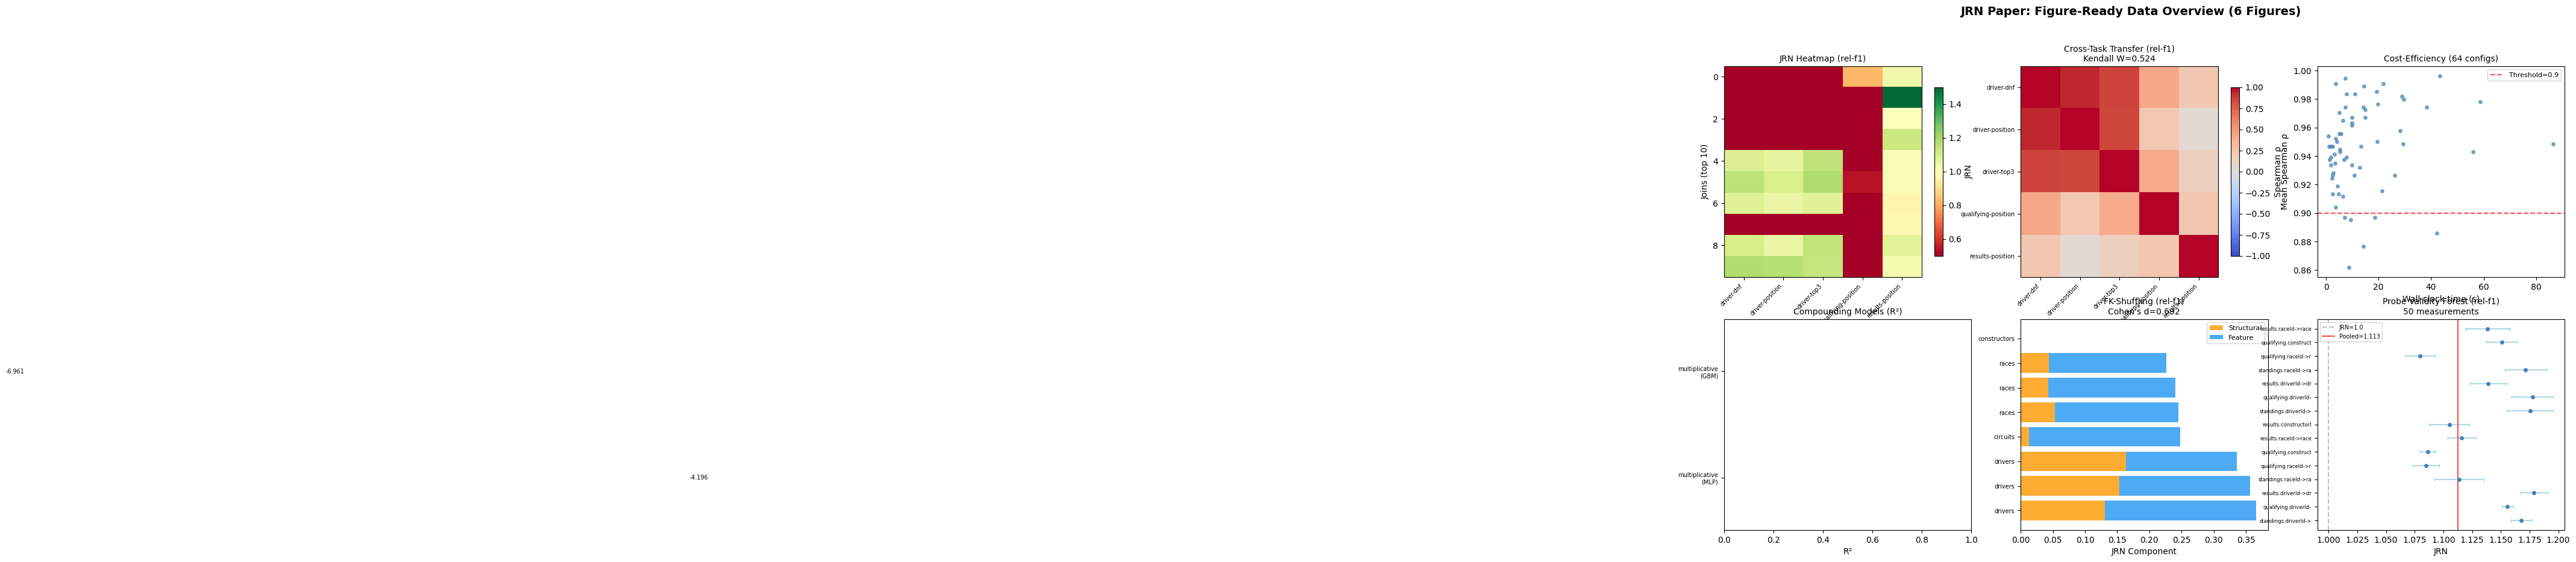

Saved figure_overview.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('JRN Paper: Figure-Ready Data Overview (6 Figures)', fontsize=14, fontweight='bold')

# ── Panel 1: JRN Heatmap ──
ax = axes[0, 0]
if heatmap_summaries:
    hs = heatmap_summaries[0]
    matrix = hs['matrix']
    # Replace NaN for display
    display_matrix = np.nan_to_num(matrix, nan=0.0)
    n_rows = min(matrix.shape[0], 10)  # limit for readability
    n_cols = matrix.shape[1]
    im = ax.imshow(display_matrix[:n_rows], cmap='RdYlGn', aspect='auto',
                   vmin=0.5, vmax=1.5)
    ax.set_title(f'JRN Heatmap ({hs["dataset"]})', fontsize=10)
    ax.set_ylabel('Joins (top 10)')
    ax.set_xlabel('Tasks')
    if n_cols <= 8:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(hs['col_labels'], rotation=45, ha='right', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8, label='JRN')
else:
    ax.text(0.5, 0.5, 'No heatmap data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('JRN Heatmap')

# ── Panel 2: Cross-Task Transfer ──
ax = axes[0, 1]
if transfer_data:
    td = transfer_data[0]
    im = ax.imshow(td['rho_matrix'], cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'Cross-Task Transfer ({td["dataset"]})\nKendall W={td["kendalls_W"]:.3f}', fontsize=10)
    n_t = len(td['task_labels'])
    if n_t <= 8:
        ax.set_xticks(range(n_t))
        ax.set_xticklabels(td['task_labels'], rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(n_t))
        ax.set_yticklabels(td['task_labels'], fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman ρ')
else:
    ax.text(0.5, 0.5, 'No transfer data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Cross-Task Transfer')

# ── Panel 3: Cost-Efficiency Convergence ──
ax = axes[0, 2]
if convergence_data:
    cd = convergence_data[0]
    ax.scatter(cd['x'], cd['y_mean'], s=15, alpha=0.7, c='steelblue')
    ax.axhline(y=cd['threshold'], color='red', linestyle='--', alpha=0.7, label=f'Threshold={cd["threshold"]}')
    ax.set_xlabel('Wall-clock time (s)')
    ax.set_ylabel('Mean Spearman ρ')
    ax.set_title(f'Cost-Efficiency ({cd["n_configs"]} configs)', fontsize=10)
    ax.legend(fontsize=8)
elif cost_bar_data:
    cb = cost_bar_data[0]
    x_pos = range(len(cb['methods']))
    ax.bar(x_pos, cb['n_models'], color=['#2196F3', '#FF9800', '#F44336', '#9E9E9E'])
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cb['methods'], fontsize=8)
    ax.set_ylabel('# Models')
    ax.set_title(f'Cost Comparison ({cb["task"]})', fontsize=10)
    ax.set_yscale('log')
else:
    ax.text(0.5, 0.5, 'No cost data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Cost-Efficiency')

# ── Panel 4: Compounding Models ──
ax = axes[1, 0]
if model_results:
    models = [mr['model'] for mr in model_results]
    r2_vals = [mr['R2'] for mr in model_results]
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#795548'][:len(models)]
    bars = ax.barh(range(len(models)), r2_vals, color=colors)
    ax.set_yticks(range(len(models)))
    labels = [f"{mr['model']}\n({mr['probe']})" if mr['probe'] else mr['model'] for mr in model_results]
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('R²')
    ax.set_title('Compounding Models (R²)', fontsize=10)
    ax.set_xlim(0, 1)
    for i, v in enumerate(r2_vals):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=7)
else:
    ax.text(0.5, 0.5, 'No model data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Compounding Models')

# ── Panel 5: FK-Shuffling Decomposition ──
ax = axes[1, 1]
if shuffling_data:
    sd = shuffling_data[0]
    n_joins = min(len(sd['join_labels']), 8)  # limit for readability
    y_pos = range(n_joins)
    short_labels = [l.split('->')[-1][:15] for l in sd['join_labels'][:n_joins]]
    ax.barh(y_pos, sd['structural'][:n_joins], color='#FF9800', alpha=0.8, label='Structural')
    ax.barh(y_pos, sd['feature'][:n_joins], left=sd['structural'][:n_joins],
            color='#2196F3', alpha=0.8, label='Feature')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(short_labels, fontsize=7)
    ax.set_xlabel('JRN Component')
    ax.set_title(f'FK-Shuffling ({sd["dataset"]})\nCohen\'s d={sd["cohens_d"]:.3f}', fontsize=10)
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No shuffling data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('FK-Shuffling')

# ── Panel 6: Probe Validity ──
ax = axes[1, 2]
if forest_data:
    fd = forest_data[0]
    rows = fd['rows'][:15]  # limit for readability
    y_pos = range(len(rows))
    means = [r['jrn_mean'] for r in rows]
    ci_lo = [r['ci_lower'] for r in rows]
    ci_hi = [r['ci_upper'] for r in rows]
    errors_lo = [m - lo for m, lo in zip(means, ci_lo)]
    errors_hi = [hi - m for m, hi in zip(means, ci_hi)]
    
    ax.errorbar(means, y_pos, xerr=[errors_lo, errors_hi], fmt='o', markersize=4,
               color='steelblue', ecolor='lightblue', capsize=2)
    ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='JRN=1.0')
    ax.axvline(x=fd['pooled_mean'], color='red', linestyle='-', alpha=0.7,
              label=f'Pooled={fd["pooled_mean"]:.3f}')
    short_labels = [r['label'].split('/')[-1][:20] for r in rows]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(short_labels, fontsize=6)
    ax.set_xlabel('JRN')
    ax.set_title(f'Probe Validity Forest ({fd["dataset"]})\n{fd["n_measurements"]} measurements', fontsize=10)
    ax.legend(fontsize=7)
elif scatter_data:
    sd = scatter_data[0]
    ax.scatter(sd['x'], sd['y'], s=15, alpha=0.7, c='steelblue')
    ax.set_xlabel('Spearman ρ')
    ax.set_ylabel('Wall-clock time (s)')
    ax.set_title(f'Probe Cost vs Quality (R²={sd["R2"]:.3f})', fontsize=10)
else:
    ax.text(0.5, 0.5, 'No validity data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Probe Validity')

plt.tight_layout()
plt.savefig('figure_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved figure_overview.png')

## Summary Table

Key metrics from the figure-ready data assembly.

In [15]:
# Print summary table
print("=" * 70)
print("{:<30} {:<25} {:>12}".format("Figure", "Key Metric", "Value"))
print("=" * 70)

# Heatmap
if heatmap_summaries:
    hs = heatmap_summaries[0]
    dim_str = str(hs['n_joins']) + "x" + str(hs['n_tasks'])
    rng_str = "[{:.2f}, {:.2f}]".format(hs['jrn_range'][0], hs['jrn_range'][1])
    print("{:<30} {:<25} {:>12}".format("JRN Heatmap", "Joins x Tasks", dim_str))
    print("{:<30} {:<25} {:>12}".format("", "JRN Range", rng_str))

# Transfer
for td in transfer_data:
    label = "Kendall W ({})".format(td['dataset'])
    val = "{:.3f}".format(td['kendalls_W'])
    print("{:<30} {:<25} {:>12}".format("Cross-Task Transfer", label, val))

# Cost
if convergence_data:
    cd = convergence_data[0]
    print("{:<30} {:<25} {:>12}".format("Cost-Efficiency", "Configs tested", str(cd['n_configs'])))
    print("{:<30} {:<25} {:>12}".format("", "Best rho", "{:.4f}".format(max(cd['y_mean']))))

if cost_bar_data:
    cb = cost_bar_data[0]
    label = "JRN models ({})".format(cb['task'])
    print("{:<30} {:<25} {:>12}".format("", label, str(cb['n_models'][0])))
    print("{:<30} {:<25} {:>12}".format("", "Exhaustive models", str(cb['n_models'][2])))

# Compounding
if model_results:
    best = max(model_results, key=lambda x: x['R2'])
    print("{:<30} {:<25} {:>12}".format("Compounding Models", "Best model", best['model']))
    print("{:<30} {:<25} {:>12}".format("", "Best R2", "{:.4f}".format(best['R2'])))

# Shuffling
for sd in shuffling_data:
    label = "Cohen d ({})".format(sd['dataset'])
    print("{:<30} {:<25} {:>12}".format("FK-Shuffling", label, "{:.3f}".format(sd['cohens_d'])))

# Validity
if forest_data:
    fd = forest_data[0]
    print("{:<30} {:<25} {:>12}".format("Probe Validity", "Pooled mean JRN", "{:.4f}".format(fd['pooled_mean'])))
    print("{:<30} {:<25} {:>12}".format("", "Measurements", str(fd['n_measurements'])))

if scatter_data:
    sd = scatter_data[0]
    print("{:<30} {:<25} {:>12}".format("", "Cheapest probe rho", "{:.4f}".format(sd['cheapest_rho'])))

print("=" * 70)
n_fig = data['metrics_agg']['n_figures']
n_pts = data['metrics_agg']['n_total_data_points']
n_exp = data['metrics_agg']['n_experiments_synthesized']
print(f"\nTotal: {n_fig:.0f} figures, {n_pts:.0f} data points from {n_exp:.0f} experiments")

Figure                         Key Metric                       Value
JRN Heatmap                    Joins x Tasks                     13x5
                               JRN Range                 [0.29, 1.63]
Cross-Task Transfer            Kendall W (rel-f1)               0.524
Cross-Task Transfer            Kendall W (rel-stack)            0.206
Cost-Efficiency                Configs tested                      64
                               Best rho                        0.9963
                               JRN models (driver-dnf)             14
                               Exhaustive models                 8192
Compounding Models             Best model                multiplicative
                               Best R2                        -4.1963
FK-Shuffling                   Cohen d (rel-f1)                 0.692
Probe Validity                 Pooled mean JRN                 1.1128
                               Measurements                        50

Total: 6 figures,